In [2]:
from sklearn.datasets import load_iris

iris = load_iris()

In [3]:
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
iris_df['species'] = iris.target
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# 직접 살펴보기
import seaborn as sns
import matplotlib.pyplot as plt

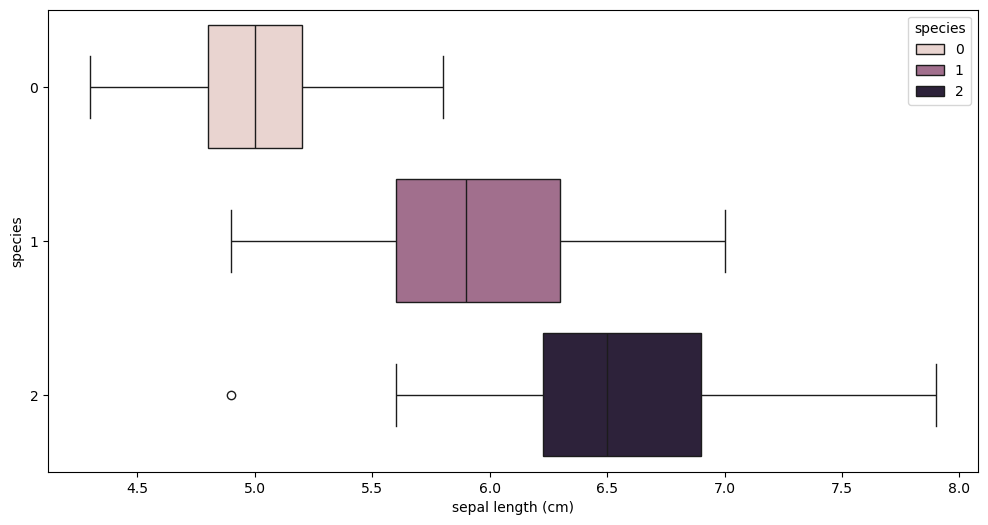

In [ ]:
# sepal length로는 기준을 나누기 모호함
plt.figure(figsize=(12, 6))

sns.boxplot(data=iris_df,
            x='sepal length (cm)',
            y='species',
            hue='species',
            orient='h')

plt.show()

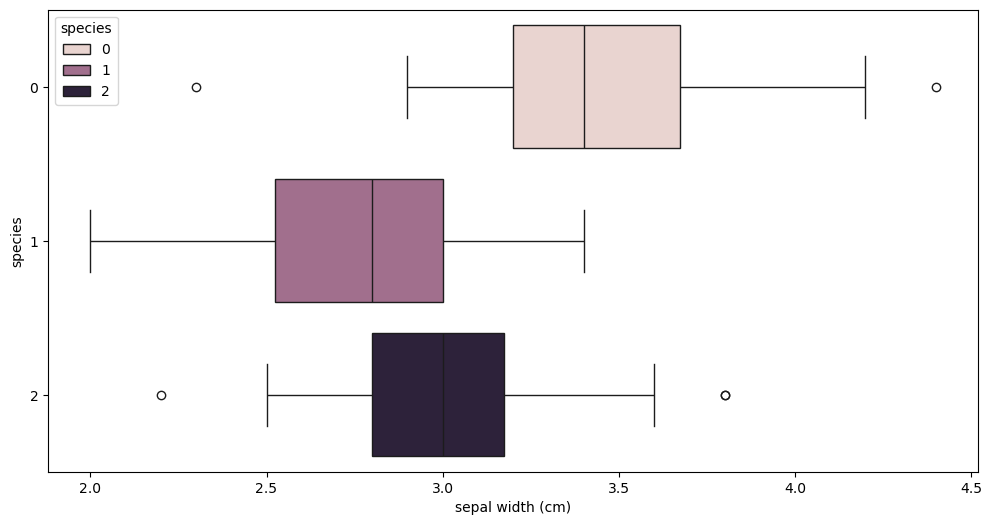

In [ ]:
# sepal width로도 기준을 나누기 모호함
plt.figure(figsize=(12, 6))

sns.boxplot(data=iris_df,
            x='sepal width (cm)',
            y='species',
            hue='species',
            orient='h')

plt.show()

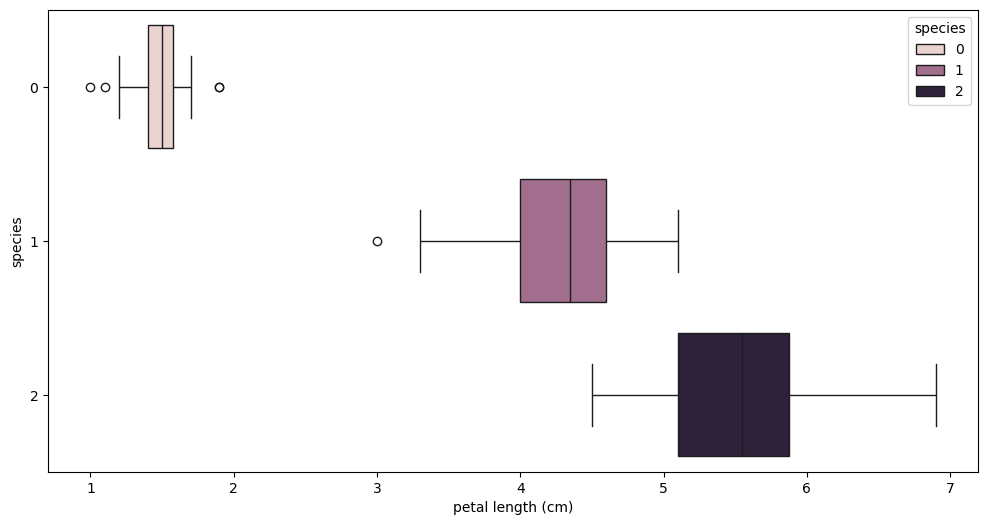

In [ ]:
# petal length로는 기준을 나눌 수 있을 것으로 보임
plt.figure(figsize=(12, 6))

sns.boxplot(data=iris_df,
            x='petal length (cm)',
            y='species',
            hue='species',
            orient='h')

plt.show()

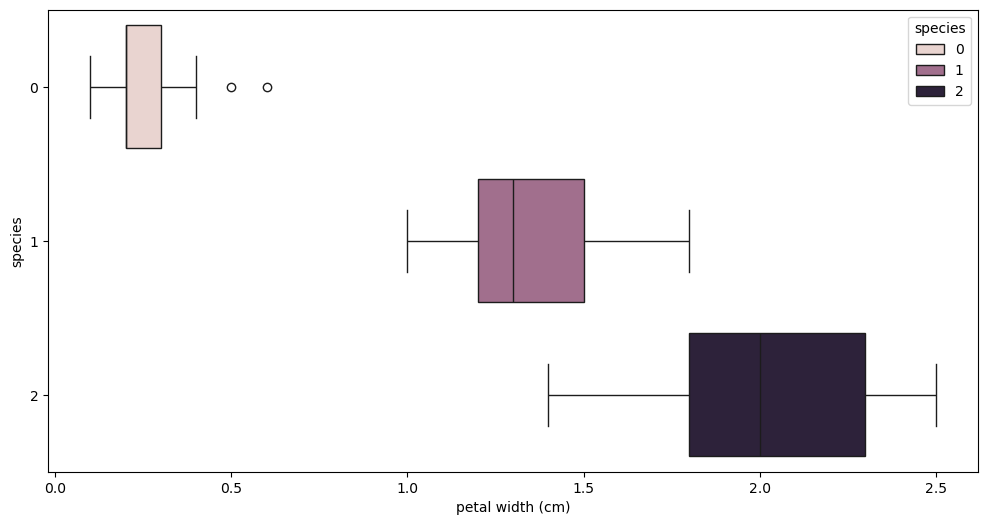

In [ ]:
# petal width로도 기준을 나눌 수 있을 것으로 보임
plt.figure(figsize=(12, 6))

sns.boxplot(data=iris_df,
            x='petal width (cm)',
            y='species',
            hue='species',
            orient='h')

plt.show()

<Figure size 800x800 with 0 Axes>

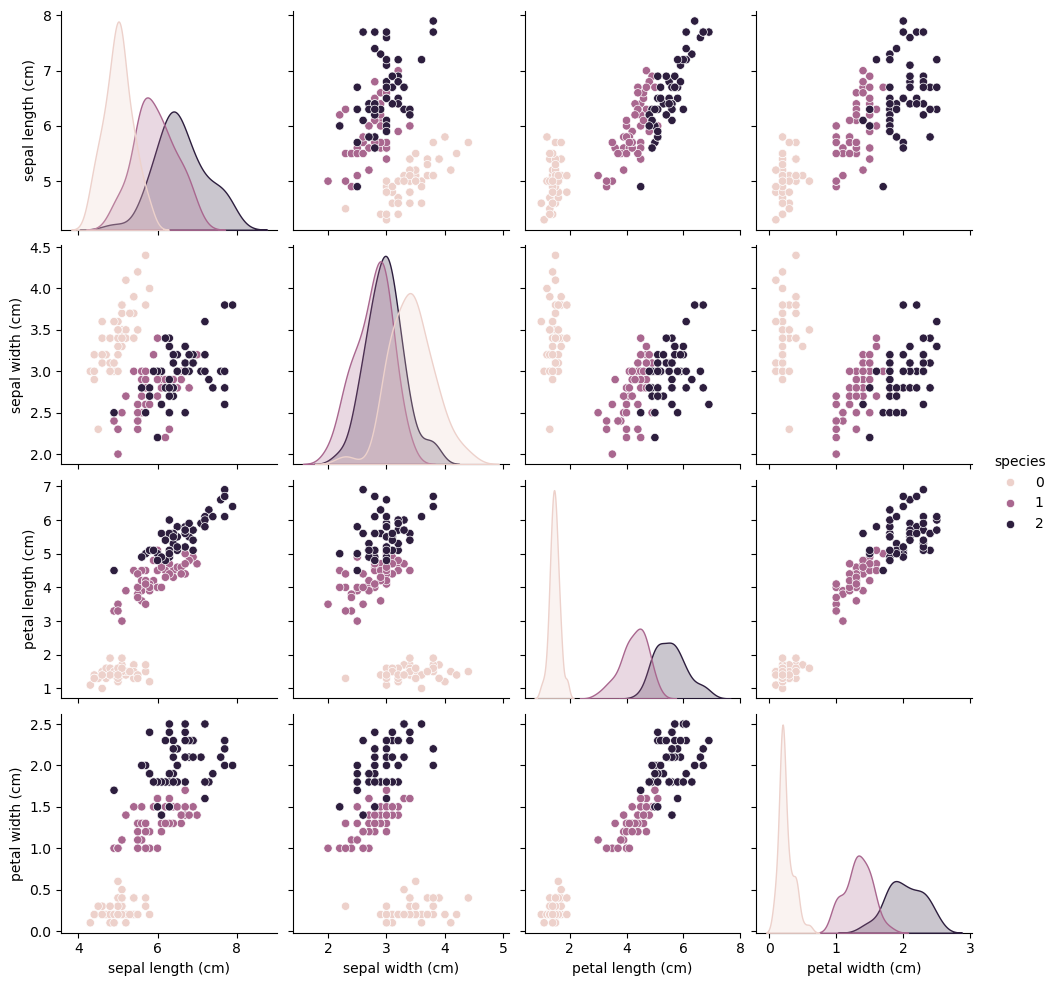

In [10]:
# 모든 특성 한번에 시각화
plt.figure(figsize=(8, 8))

sns.pairplot(iris_df, hue='species')

plt.show()

<Figure size 800x800 with 0 Axes>

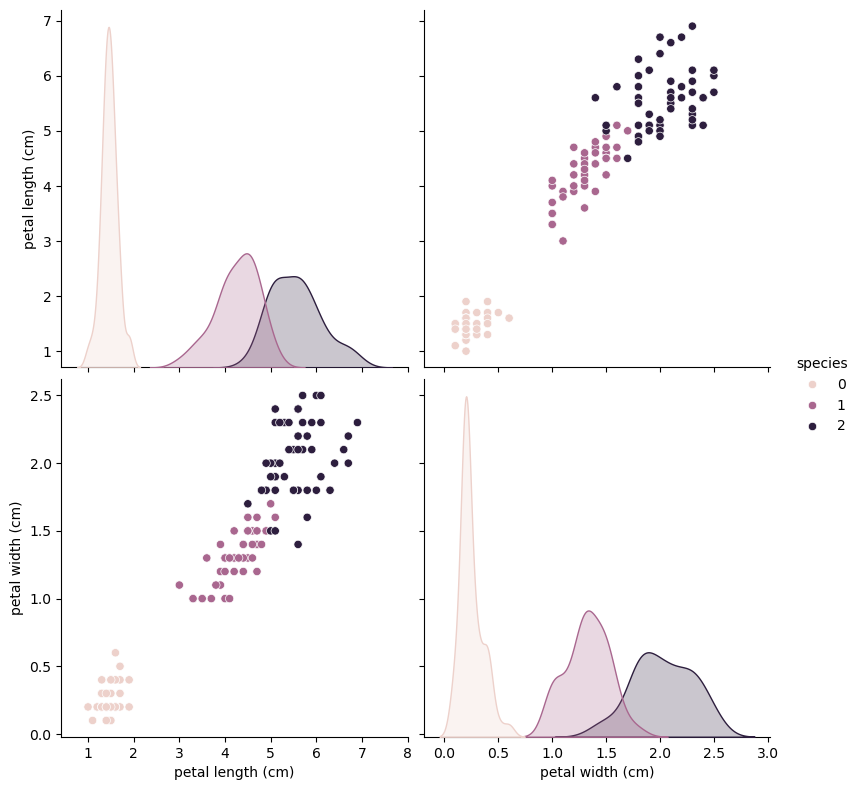

In [11]:
# petal의 특성으로만 시각화
plt.figure(figsize=(8, 8))

sns.pairplot(data=iris_df,
             vars=['petal length (cm)', 'petal width (cm)'],
             hue='species',
             height=4)

plt.show()

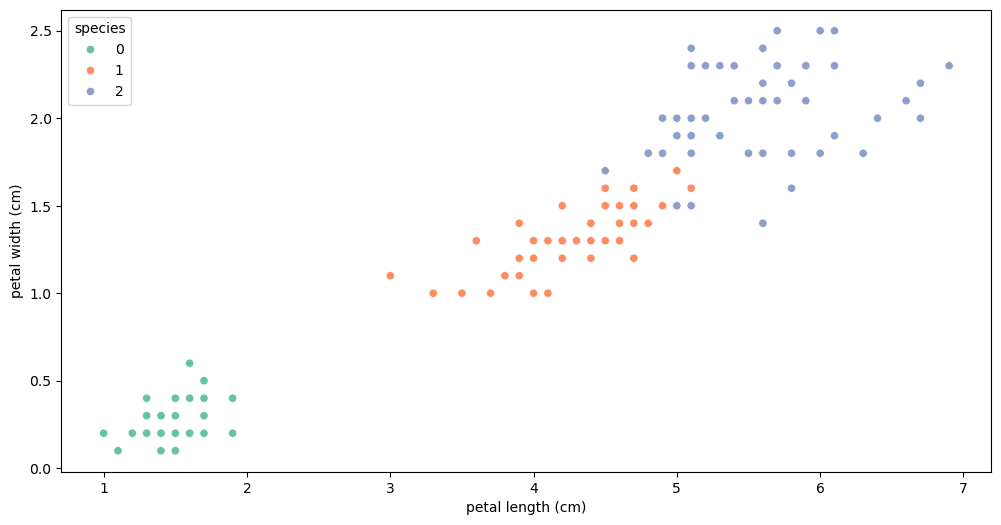

In [12]:
# 산점도
plt.figure(figsize=(12, 6))

sns.scatterplot(data=iris_df,
                x='petal length (cm)',
                y='petal width (cm)',
                hue='species',
                palette='Set2')

plt.show()

In [13]:
# 구분이 잘되는 0번 species 제외
iris_12 = iris_df[iris_df['species'] != 0]
iris_12.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  100 non-null    float64
 1   sepal width (cm)   100 non-null    float64
 2   petal length (cm)  100 non-null    float64
 3   petal width (cm)   100 non-null    float64
 4   species            100 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 4.3 KB


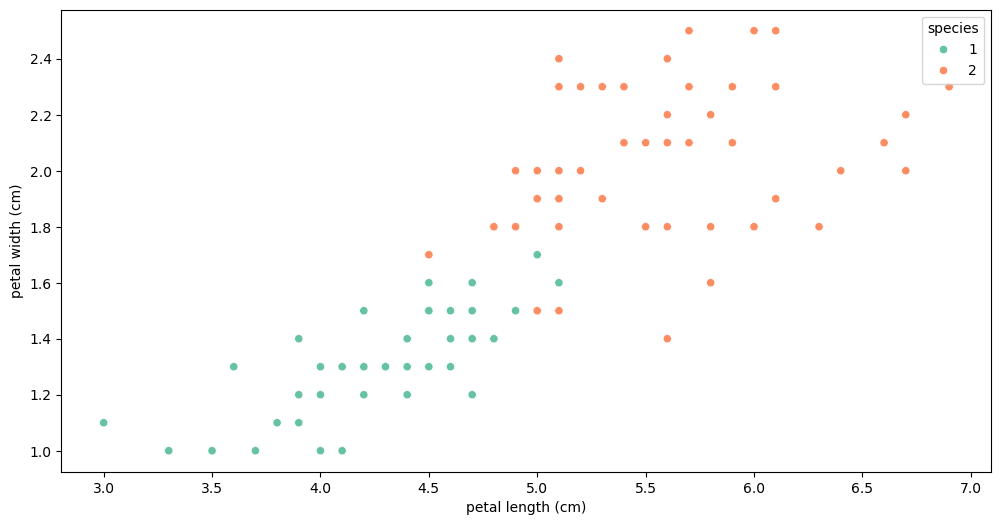

In [14]:
# 산점도
plt.figure(figsize=(12, 6))

sns.scatterplot(data=iris_12,
                x='petal length (cm)',
                y='petal width (cm)',
                hue='species',
                palette='Set2')

plt.show()

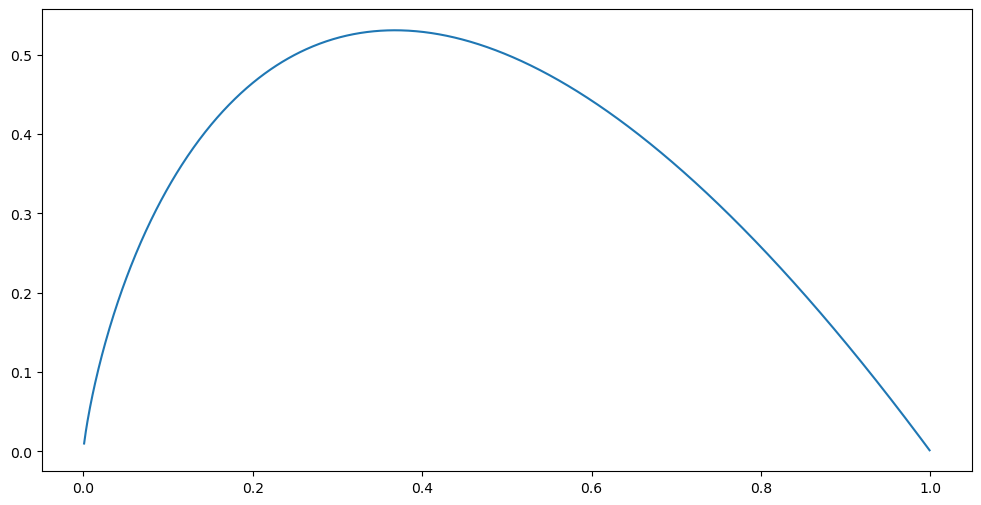

In [15]:
# 엔트로피 수식
import numpy as np

p = np.arange(0.001, 1, 0.001)

plt.figure(figsize=(12, 6))

plt.plot(p, -p * np.log2(p))

plt.show()

In [16]:
# ex. 만약 전체 공간에 빨간공 10개, 파란공 6개가 있을 때 엔트로피

-(10 / 16) * np.log2(10 / 16) - (6 / 16) * np.log2(6 / 16)

0.954434002924965

In [17]:
# 위 전체 공간을 나누어 
# (빨간공 7개, 파란공 1개), (빨간공 3개, 파란공 5개) 일때 엔트로피
(8 / 16) * (-(7 / 8) * np.log2(7 / 8) - (1 / 8) * np.log2(1 / 8)) + \
(8 / 16) * (-(3 / 8) * np.log2(3 / 8) - (5 / 8) * np.log2(5 / 8))

0.7489992230622807

In [ ]:
# 위 전체 공간에서의 지니지수
1 - (6 / 16)**2 - (10 / 16)**2

0.46875

In [19]:
# 나누었을 때 지니지수
(1 - 0.5) * (1 - (7 / 8) ** 2 - (1 / 8) ** 2) + \
(1 - 0.5) * (1 - (3 / 8) ** 2 - (5 / 8) ** 2)

0.34375

In [22]:
# Decision Tree (petal length, petal width만 사용)
from sklearn.tree import DecisionTreeClassifier

iris_tree = DecisionTreeClassifier()
iris_tree.fit(iris.data[:, 2:], iris.target)

DecisionTreeClassifier()

In [ ]:
# 평가
from sklearn.metrics import accuracy_score

y_pred_train = iris_tree.predict(iris.data[:, 2:])
accuracy_score(iris.target, y_pred_train)

0.9933333333333333

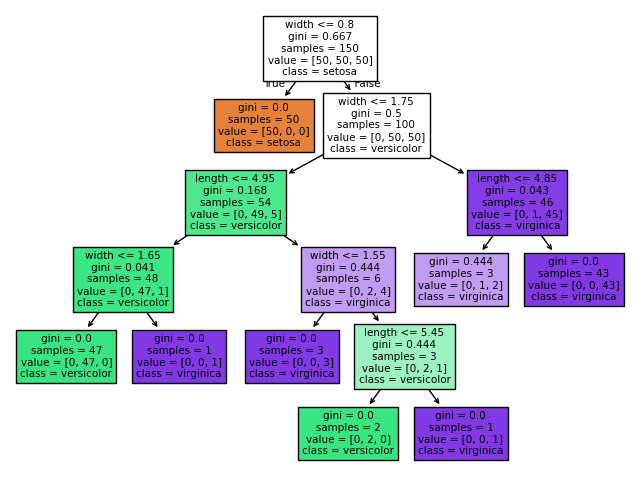

In [30]:
# Tree 확인
from sklearn import tree

fig = plt.figure(figsize=(8, 6))

_ = tree.plot_tree(iris_tree,
                   feature_names=['length', 'width'],
                   class_names=list(iris.target_names),
                   filled=True)

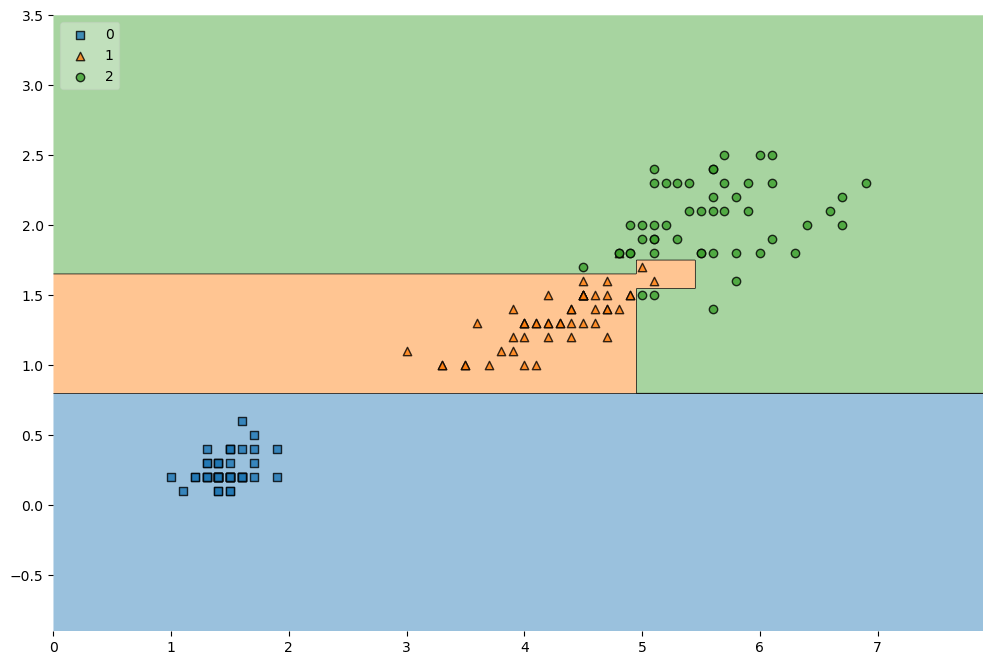

In [ ]:
# 전체 데이터셋을 훈련용으로 사용하였을 때
# 훈련 데이터셋에 과적합된 것을 볼 수 있음
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(12, 8))

plot_decision_regions(X=iris.data[:, 2:],
                      y=iris.target,
                      clf=iris_tree,
                      legend=2)

plt.show()

In [ ]:
# 그렇다면 과연 이 수치가 믿을만한 수치인가?
y_pred_train = iris_tree.predict(iris.data[:, 2:])
accuracy_score(iris.target, y_pred_train)

0.9933333333333333

In [ ]:
# Data Split (데이터 비율이 맞지 않음..)
from sklearn.model_selection import train_test_split

features = iris.data[:, 2:]
labels = iris.target

x_train, x_test, y_train, y_test = train_test_split(features,
                                                    labels,
                                                    test_size=0.2,
                                                    random_state=13)
np.unique(y_test, return_counts = True)

(array([0, 1, 2]), array([ 9,  8, 13], dtype=int64))

In [ ]:
# stratify로 비율 맞추기
features = iris.data[:, 2:]
labels = iris.target

x_train, x_test, y_train, y_test = train_test_split(features,
                                                    labels,
                                                    test_size=0.2,
                                                    stratify=labels,
                                                    random_state=13)
np.unique(y_test, return_counts = True)

(array([0, 1, 2]), array([10, 10, 10], dtype=int64))

In [39]:
# 나눈 데이터셋으로 다시 학습
# 과적합을 방지하기 위해 max_depth도 설정
iris_tree = DecisionTreeClassifier(max_depth=2, random_state=13)
iris_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

In [ ]:
# 정확도는 좀 떨어졌지만 일반화가 더 잘 이루어짐
y_pred_train = iris_tree.predict(x_train)
accuracy_score(y_train, y_pred_train)

0.95

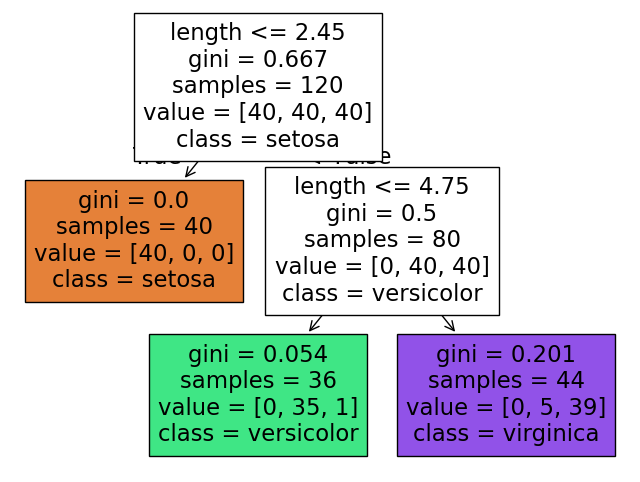

In [ ]:
# 깊이도 줄어들고 기준도 적어진 것을 볼 수 있음
fig = plt.figure(figsize=(8, 6))

_ = tree.plot_tree(iris_tree,
                   feature_names=['length', 'width'],
                   class_names=list(iris.target_names),
                   filled=True)

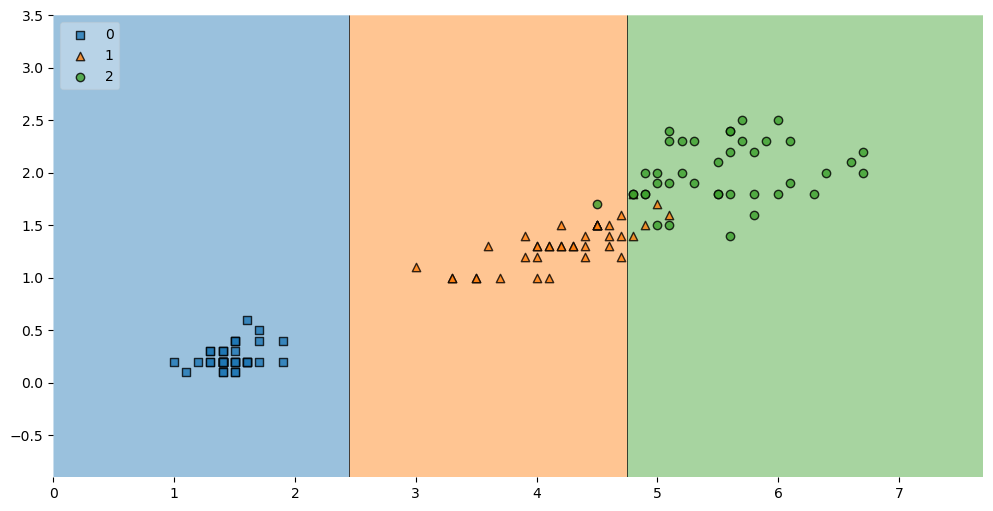

In [ ]:
# 전체 데이터 셋으로 학습시킨 것보다 경계가 더 자연스러워짐
plt.figure(figsize=(12, 6))

plot_decision_regions(X=x_train,
                      y=y_train,
                      clf=iris_tree,
                      legend=2)

plt.show()

In [44]:
# 테스트셋으로 정확도 계산
y_pred_test = iris_tree.predict(x_test)
accuracy_score(y_test, y_pred_test)

0.9666666666666667

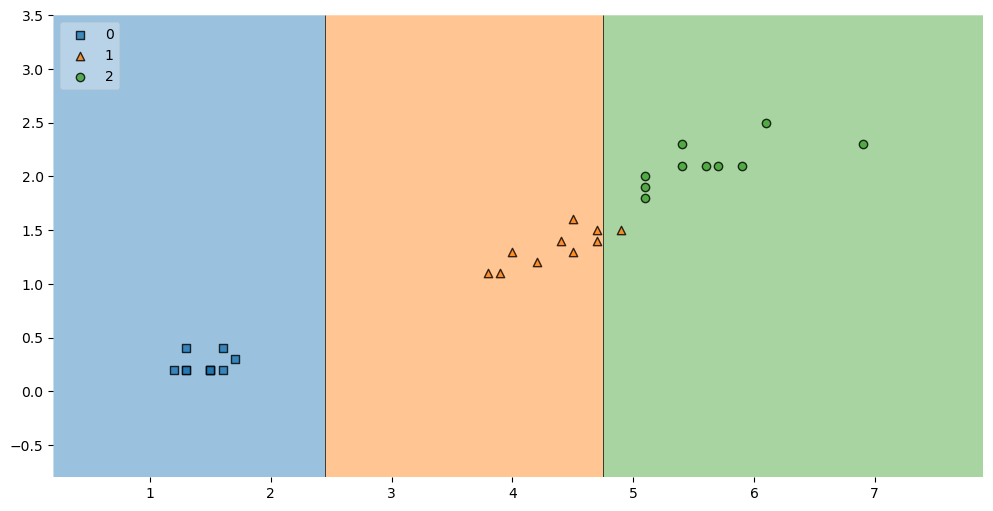

In [ ]:
# 모델의 결정경계에 테스트셋 데이터 그리기 (하나 틀림)
plt.figure(figsize=(12, 6))

plot_decision_regions(X=x_test,
                      y=y_test,
                      clf=iris_tree,
                      legend=2)

plt.show()

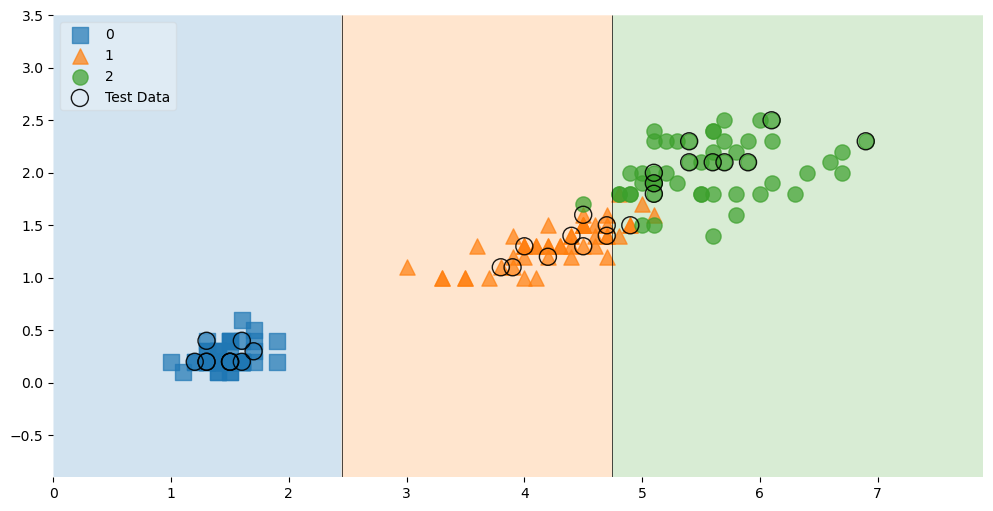

In [46]:
# 결정경계에 테스트셋 데이터 강조해서 함께 시각화
scatter_highlight_kwargs = {'s': 150,
                            'label': 'Test Data',
                            'alpha': 0.9}
scatter_kwargs = {'s': 120,
                  'edgecolor': None,
                  'alpha': 0.7}

plt.figure(figsize=(12, 6))

plot_decision_regions(X=features,
                      y=labels,
                      X_highlight=x_test,
                      clf=iris_tree,
                      legend=2,
                      scatter_highlight_kwargs=scatter_highlight_kwargs,
                      scatter_kwargs=scatter_kwargs,
                      contourf_kwargs={'alpha': 0.2})

plt.show()

In [47]:
# 전체 컬럼으로 학습
features = iris.data
labels = iris.target

x_train, x_test, y_train, y_test = train_test_split(features,
                                                    labels,
                                                    test_size=0.2,
                                                    stratify=labels,
                                                    random_state=13)

iris_tree = DecisionTreeClassifier(max_depth=2, random_state=13)
iris_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

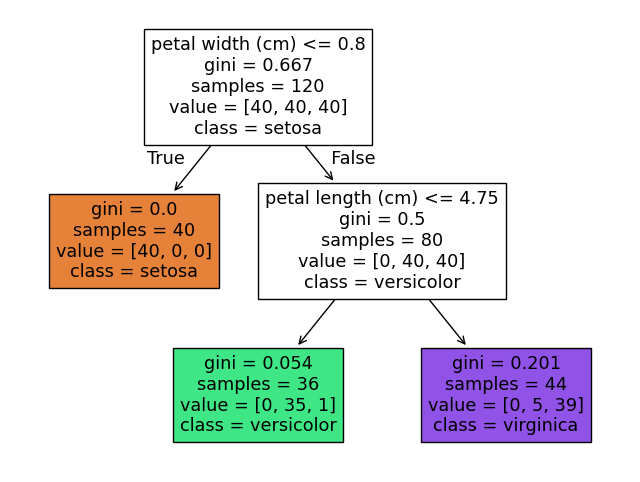

In [ ]:
# petal length, width만 사용했을 때와 똑같이 
# sepal length, width는 기준을 나누는데 사용하지 않음
fig = plt.figure(figsize=(8, 6))

_ = tree.plot_tree(iris_tree,
                   feature_names=list(iris.feature_names),
                   class_names=list(iris.target_names),
                   filled=True)

In [51]:
# 만약 이러한 데이터가 주어진다면 예측 결과
test_data = [[4.3, 2., 1.2, 1.0]]
iris_tree.predict_proba(test_data)

array([[0.        , 0.97222222, 0.02777778]])

In [ ]:
# 컬럼(피쳐)별 중요도
# 예상대로 sepal length와 width는 예측에 중요하지 않음
iris_clf_model = dict(zip(iris.feature_names, iris_tree.feature_importances_))
iris_clf_model

{'sepal length (cm)': 0.0,
 'sepal width (cm)': 0.0,
 'petal length (cm)': 0.421897810218978,
 'petal width (cm)': 0.578102189781022}

In [53]:
test_data = [[9999999, 9999999., 0., 0.]]
iris.target_names[iris_tree.predict(test_data)]

array(['setosa'], dtype='<U10')

In [54]:
test_data = [[-9999999, -9999999., 0., 0.]]
iris.target_names[iris_tree.predict(test_data)]

array(['setosa'], dtype='<U10')